# ⚾ MLB Pitch Bot - Exploratory Data Analysis

In this notebook, we explore the relationships between our engineered features (pitcher tendencies, batter stats, situational context) and the types of pitches actually thrown.

## Objectives:
1.  **Feature Impact**: How much do batter stats (OBP, Whiff Rate) correlate with pitch selection?
2.  **Situation Analysis**: How does pitch family distribution change in 2-strike vs 3-ball counts?
3.  **Tendency Validation**: Do 'global tendencies' hold up in high-pressure counts?

In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Robust project root detection
current_path = Path(os.getcwd())
if (current_path / "src").exists():
    root = current_path
elif (current_path.parent / "src").exists():
    root = current_path.parent
else:
    # Fallback to absolute if known (common for this environment)
    root = Path("/Users/michael/Documents/Data Projects/mlb-pitch-bot")

if str(root) not in sys.path:
    sys.path.append(str(root))

from src.database import query_all_pitches
from src.dataset_generator import add_features
from src.batter_tendency_processing import get_batter_features
from src.features import _classify_pitch_family

sns.set_theme(style="whitegrid", palette="muted")
print(f"Setup Complete. Project root: {root}")

Setup Complete. Project root: /Users/michael/Documents/Data Projects/mlb-pitch-bot


## 1. Load and Prepare Data
We pull data from the SQLite DB and enrich it with our full feature set.

In [7]:
# Load raw data
df = query_all_pitches()
print(f"Loaded {len(df)} pitches from DB.")

# Add Pitcher features
df = add_features(df)

# Add Batter features (Using DB-calculated metrics)
# Set use_api=True if you want OBP/K%/BB% from MLB API (will take a few minutes)
print("Calculating batter tendencies (Whiff, Chase)...")
batter_features = get_batter_features(df, use_api=False) 
df = df.merge(batter_features, on="batter_id", how="left")

# Target variable
df["pitch_family"] = df["pitch_type"].apply(_classify_pitch_family)
df = df[df["pitch_family"] != "Other"] # Filter noise

print("Feature enrichment complete.")

Loaded 15565 pitches from DB.
    Adding situational features...
Calculating batter tendencies (Whiff, Chase)...
Feature enrichment complete.


## 2. Pitch Selection by Count
Let's see how the frequency of Fastballs, Breaking balls, and Offspeed pitches shifts depending on the count.

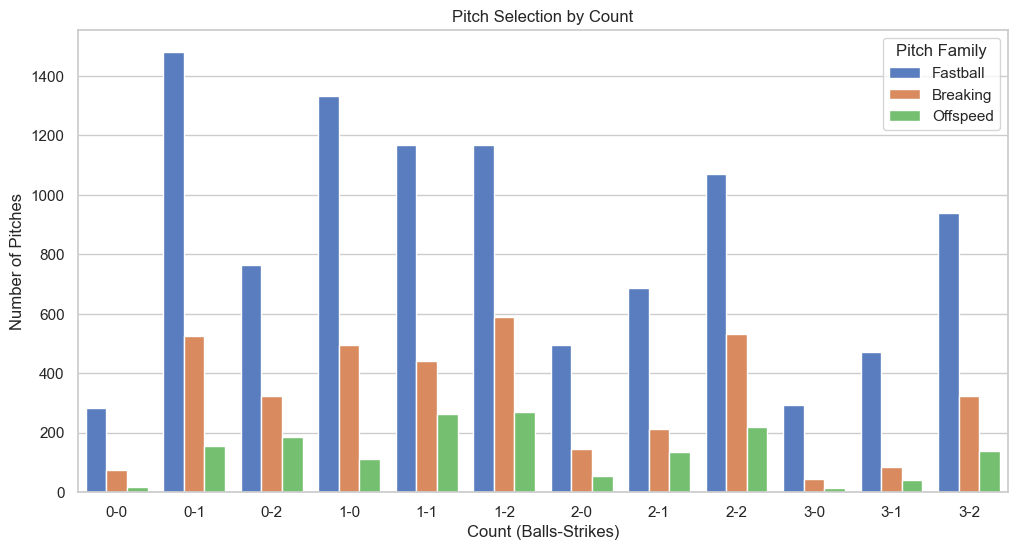

In [8]:
df["count_str"] = df["balls"].astype(str) + "-" + df["strikes"].astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="count_str", hue="pitch_family", 
              order=sorted(df["count_str"].unique()))
plt.title("Pitch Selection by Count")
plt.ylabel("Number of Pitches")
plt.xlabel("Count (Balls-Strikes)")
plt.legend(title="Pitch Family")
plt.show()

## 3. Batter Vulnerability vs. Pitch Thrown
Do pitchers actually 'attack' a batter's weakness? We'll plot the Batter's Whiff Rate (on specific families) vs. the probability that they actually see that pitch.

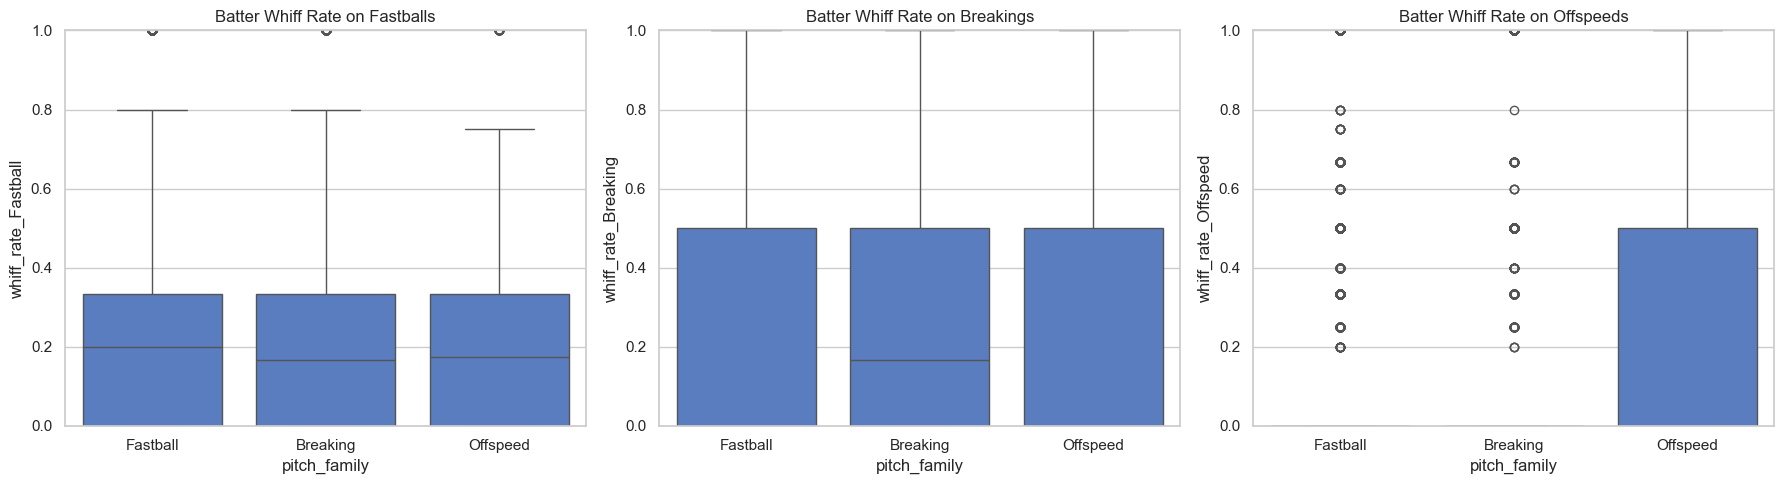

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

families = ["Fastball", "Breaking", "Offspeed"]
for i, fam in enumerate(families):
    whiff_col = f"whiff_rate_{fam}"
    if whiff_col in df.columns:
        sns.boxplot(ax=axes[i], data=df, x="pitch_family", y=whiff_col)
        axes[i].set_title(f"Batter Whiff Rate on {fam}s")
        axes[i].set_ylim(0, 1)
    else:
        axes[i].set_title(f"Metric {whiff_col} not found")

plt.tight_layout()
plt.show()

## 4. Feature Importance Heatmap
Correlation between situational features and the target (encoded).

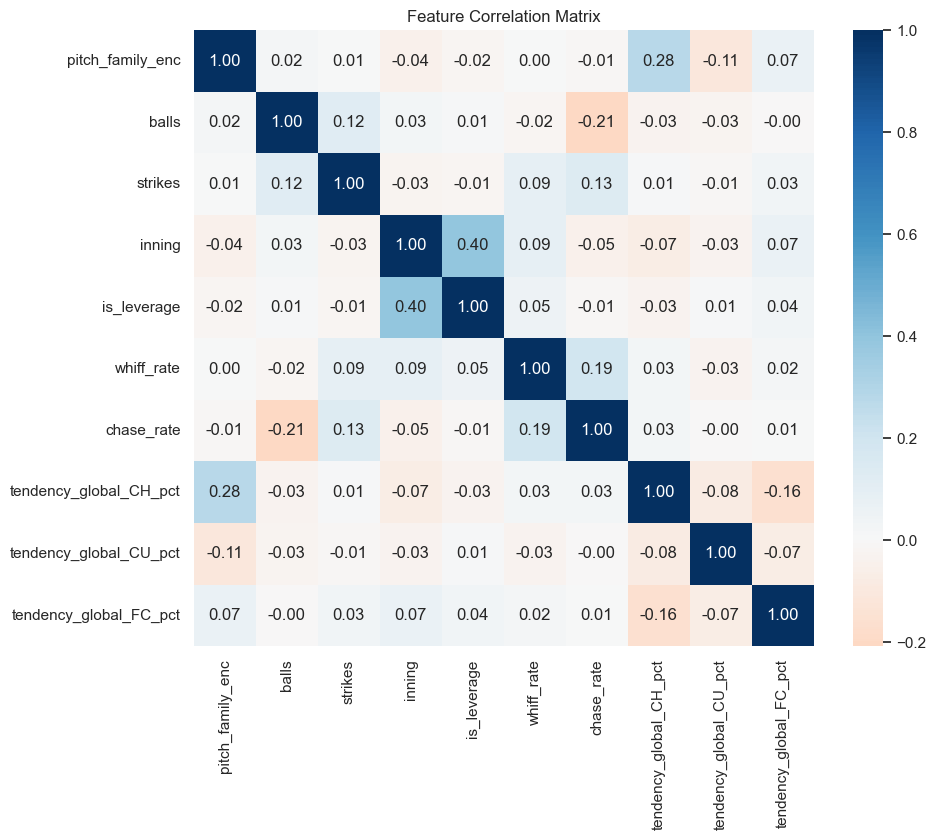

In [10]:
from sklearn.preprocessing import LabelEncoder

eda_df = df.copy()
le = LabelEncoder()
eda_df["pitch_family_enc"] = le.fit_transform(eda_df["pitch_family"])

# Select a subset of numeric features
interest_cols = [
    "pitch_family_enc", "balls", "strikes", "inning", "is_leverage", 
    "whiff_rate", "chase_rate", "obp", "k_pct", "bb_pct"
]
# Add global tendency columns if they exist
interest_cols += [c for c in eda_df.columns if "tendency_global" in c and "pct" in c][:3]

# Filter to only existing columns to avoid KeyError
valid_cols = [c for c in interest_cols if c in eda_df.columns]
corr = eda_df[valid_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="RdBu", fmt=".2f", center=0)
plt.title("Feature Correlation Matrix")
plt.show()